In [1]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi 
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [2]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [3]:
fdtdApi = lumapi.FDTD(hide = False)

## units
um = 1e-6
nm = 1e-9

#wavelength

wavelength = 1550 * nm
start_wavelength = 1500 * nm
stop_wavelength = 1600 * nm

## Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

## Dimensions

wvg_width = 450 * nm
wvg_height = 220 * nm
wvg_length = 3*um
WM = 7 * um
taper_length = 15 * um
taper_max_height = 1.5 * um
L = 178.5 * um

n_c = 1.5 # Refractive index of cladding
n_r = 3.5 # Refractive index of core
sigma = 0 # Conductivity of core
N = 2 # Number of desired imagens in the output

n_eff_array = np.loadtxt('neff_core.txt') # Exporting the effective index of the modes
beta_array = (2*np.pi/wavelength)*n_eff_array

We = WM + (wavelength / np.pi) * np.power(n_c / n_r,  2*sigma) * np.power(n_r**2 - n_c**2, -0.5)

In [4]:
fdtdApi.addrect()
fdtdApi.set('name', 'central box')
fdtdApi.set('x', 0)
fdtdApi.set('x span', L)
fdtdApi.set('y', 0)
fdtdApi.set('y span', WM)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

x_tapers = [(L+taper_length)/2, (L+taper_length)/2, -(L+taper_length)/2, -(L+taper_length)/2]
y_tapers = [We/6, -We/6, We/6, -We/6]
width_l_tapers = [taper_max_height, taper_max_height, wvg_width, wvg_width]
width_r_tapers = [wvg_width, wvg_width, taper_max_height, taper_max_height]

for i in range(0,4,1):
    fdtdApi.addobject('linear_taper')
    fdtdApi.set('name', 'taper_%d' %(i+1))
    fdtdApi.set('x', x_tapers[i])
    fdtdApi.set('len', taper_length)
    fdtdApi.set('y', y_tapers[i])
    fdtdApi.set('width_l', width_l_tapers[i])
    fdtdApi.set('width_r', width_r_tapers[i])
    fdtdApi.set('z', 0)
    fdtdApi.set('thickness', wvg_height)
    fdtdApi.set('angle_side', 90)
    fdtdApi.set('material', material)

x_guias = [(L+2*taper_length+wvg_length)/2, (L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2]

for i in range(0,4,1):
    fdtdApi.addrect()
    fdtdApi.set('name', 'wvg_%d' %(i+1))
    fdtdApi.set('x', x_guias[i])
    fdtdApi.set('x span', wvg_length)
    fdtdApi.set('y', y_tapers[i])
    fdtdApi.set('y span', wvg_width)
    fdtdApi.set('z', 0)
    fdtdApi.set('z span', wvg_height)
    fdtdApi.set('material', material)

## Definindo o solver FDTD ##

In [5]:
x_fdtd = 0
x_span_fdtd = L + 2*taper_length + wvg_length
y_fdtd = 0
y_span_fdtd = 4*WM
z_fdtd = 0
z_span_fdtd = 4*um

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy = 3

z_min_bc = 'Symmetric'

In [6]:
## add solver
fdtdApi.addfdtd()
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)
fdtdApi.set('z span', z_span_fdtd)

## mesh accuracy, simulation time and frequency points
fdtdApi.set('simulation time', 5*(L + 2*taper_length + wvg_length)/c)
fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('z min bc', z_min_bc)

## add ports 

fdtdApi.addport()
fdtdApi.set('name', 'port_1')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', x_guias[2] + wvg_length/4)
fdtdApi.set('x span', 0)
fdtdApi.set('y', y_tapers[2])
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_2')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', x_guias[0] - wvg_length/4)
fdtdApi.set('x span', 0)
fdtdApi.set('y', y_tapers[0])
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_3')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', x_guias[3] + wvg_length/4)
fdtdApi.set('x span', 0)
fdtdApi.set('y', y_tapers[3])
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_4')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', x_guias[1] - wvg_length/4)
fdtdApi.set('x span', 0)
fdtdApi.set('y', y_tapers[1])
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*um)

## add monitors

#fdtdApi.addindex()
#fdtdApi.set('name', 'index')
#fdtdApi.set('x', x_fdtd)
#fdtdApi.set('x span', x_span_fdtd)
#fdtdApi.set('y', y_fdtd)
#fdtdApi.set('y span', y_span_fdtd)
#fdtdApi.set('z', z_fdtd)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)

fdtdApi.addmovie()
fdtdApi.set('name', 'movie')
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)

## Salva o arquivo
fdtdApi.save('MMI_FDTD')

In [7]:
fdtdApi.run()

In [8]:
# importa o campo elétrico - abs
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile')))

indxLambda = np.argmin(np.abs(nu2lambda(fdtdApi.getdata('profile', 'f')) - 1.55*um))
x_efield = fdtdApi.getdata('profile', 'x')
y_efield = fdtdApi.getdata('profile', 'y')
wavelength_array = nu2lambda(fdtdApi.getdata('profile', 'f'))[:,0]
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

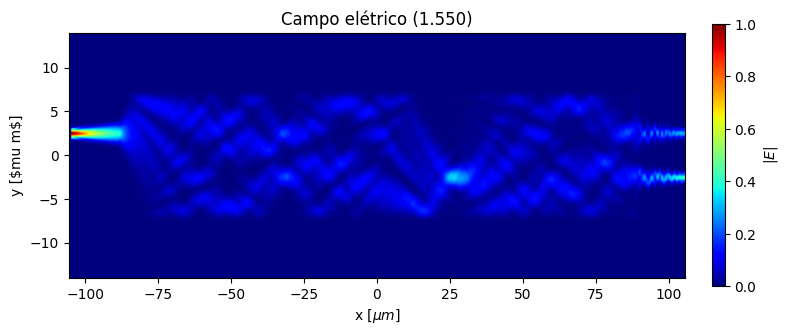

In [9]:
# Escala linear
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)

im = ax.imshow(np.rot90(eField[:,:,indxLambda]/np.max(eField[:,:,indxLambda])), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1)

colorbar = plt.colorbar(im, fraction = 0.02, pad =0.04, label = r'$|E|$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [\$mu m$]')
ax.set_title(r'Campo elétrico (%4.3f)' %(wavelength_array[indxLambda]/um))
ax.set_aspect(3)

plt.tight_layout()
plt.show()

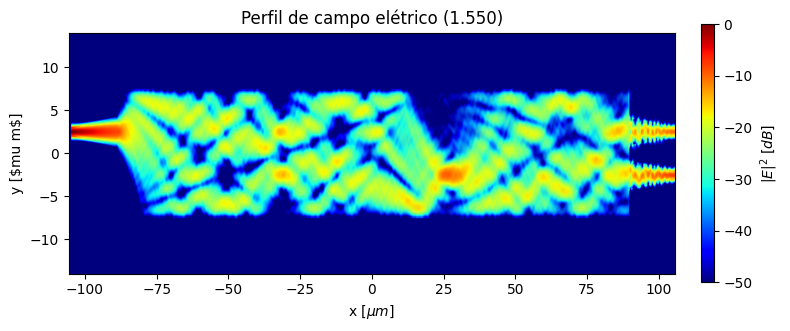

In [10]:
eFiled2 = np.power(eField[:,:,indxLambda], 2)
eField2 = eFiled2 / np.max(eFiled2)
eField2_dB = 10*np.log10(eField2)

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)

im = ax.imshow(np.rot90(eField2_dB), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin = -50, vmax = 0)

colorbar = plt.colorbar(im, fraction = 0.02, pad =0.04, label = r'$|E|^2$ $[dB]$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [\$mu m$]')
ax.set_title(r'Perfil de campo elétrico (%4.3f)' %(wavelength_array[indxLambda]/um))
ax.set_aspect(3)

plt.tight_layout()
plt.show()

C:\Users\LucasGabriel\AppData\Local\Temp\ipykernel_9780\2130589577.py:8: RuntimeWarning: invalid value encountered in log10
  ax[1].plot(ports['lambda']/um, 10*np.log10(ports['T']), label = 'Porta %d' %i, linewidth = 1.5)


Text(0.5, 1.0, 'Transmissão [$dB$] x Comprimento de Onda')

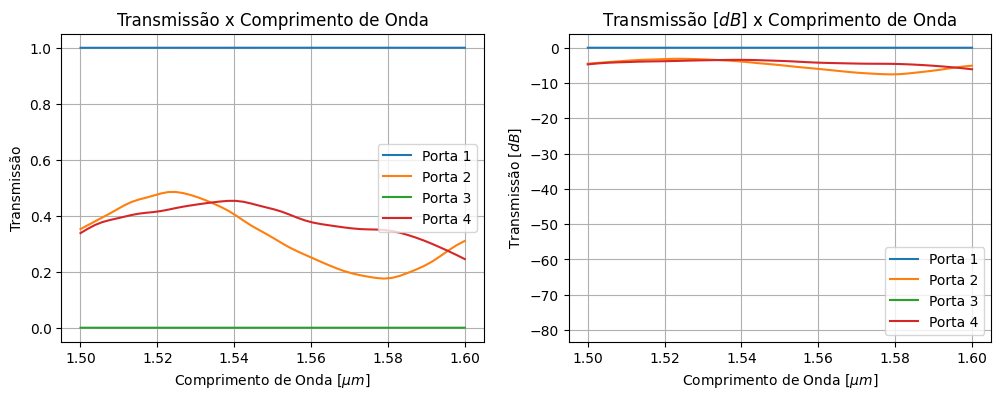

In [11]:
#Transmissão do dispositivo em cada porta

fig, ax = plt.subplots(1,2, figsize=(12,4))

for i in range(1,5,1):
    ports = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    ax[0].plot(ports['lambda']/um, np.abs(ports['T']), label = 'Porta %d' %i, linewidth = 1.5)
    ax[1].plot(ports['lambda']/um, 10*np.log10(ports['T']), label = 'Porta %d' %i, linewidth = 1.5)

ax[0].grid(True)
ax[0].legend(loc = 'best')
ax[0].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão')
ax[0].set_title(r'Transmissão x Comprimento de Onda')

ax[1].grid(True)
ax[1].legend(loc = 'best')
ax[1].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão [$dB$]')
ax[1].set_title(r'Transmissão [$dB$] x Comprimento de Onda')

Text(0.5, 1.0, 'Transmissão total [$dB$] x Comprimento de Onda')

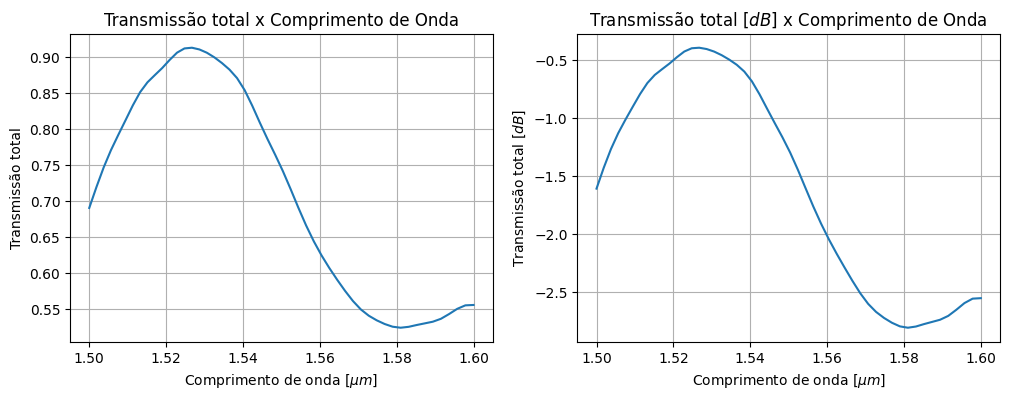

In [12]:
# Perda de inserção do dispositivo

T2 = (fdtdApi.getresult('FDTD::ports::port_2', 'T'))['T']
T3 = (fdtdApi.getresult('FDTD::ports::port_4', 'T'))['T']
wavelength_array = (fdtdApi.getresult('FDTD::ports::port_2', 'T'))['lambda']

total_transmission = T2 + T3
total_transmission_dB = 10*np.log10(total_transmission)

fig, ax = plt.subplots(1,2, figsize = (12,4))

ax[0].plot(wavelength_array/um, total_transmission, linewidth = 1.5)
ax[0].grid(True)
ax[0].set_xlabel(r'Comprimento de onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão total')
ax[0].set_title(r'Transmissão total x Comprimento de Onda')

ax[1].plot(wavelength_array/um, total_transmission_dB, linewidth = 1.5)
ax[1].grid(True)
ax[1].set_xlabel(r'Comprimento de onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão total [$dB$]')
ax[1].set_title(r'Transmissão total [$dB$] x Comprimento de Onda')

In [13]:
fdtdApi.close()